# 04 · Did the subsidy work?

**Design — dose-response difference-in-differences.** Treatment is a *continuous
intensity* (CRM machines, harmonised to `dose_z`), switched on from 2018-19:

$$\log\_dm_{it} = \alpha_i + \gamma_t + \beta\,(dose_i \times post_t) + X_{it}\theta + \varepsilon_{it}$$

with district ($\alpha_i$) and year ($\gamma_t$) fixed effects, district-clustered SEs.
$\beta<0$ ⇒ higher-intensity districts cut burning more after the subsidy.

In [1]:
import sys, os, warnings
warnings.filterwarnings('ignore')
ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
os.chdir(ROOT)
if os.path.join(ROOT, 'src') not in sys.path: sys.path.insert(0, os.path.join(ROOT, 'src'))
import pandas as pd, numpy as np
from IPython.display import Image, display
pd.set_option('display.width', 140); pd.set_option('display.max_columns', 40)
print('project root:', ROOT)

project root: E:\New folder (3)


In [2]:
import fire_policy.causal as CA
df = CA.load_causal_frame()
print(f'{len(df)} district-years, {df.year.min()}-{df.year.max()}')
display(df.head())

301 district-years, 2012-2018


,state,district,year,dm_kg,dm_tonnes,log_dm,crm_machines,crm_share,dose_z,crm_subsidy_lakh,area_km2,is_punjab,precip_sum,dry_days,wind_max_mean,et0_sum,tmax_mean
0,Haryana,Ambala,2012,2.774058e+07,27740.575920,10.230688,383.0,0.068848,0.765866,279.0,1458.548974,0,123.9,69,12.182449,332.39,28.513061
1,Haryana,Ambala,2013,4.723451e+07,47234.509395,10.762901,383.0,0.068848,0.765866,279.0,1458.548974,0,107.9,52,12.252891,326.03,28.781633
2,Haryana,Ambala,2014,3.922764e+07,39227.642954,10.577162,383.0,0.068848,0.765866,279.0,1458.548974,0,195.8,66,12.921978,353.68,29.395604
3,Haryana,Ambala,2015,3.840518e+07,38405.176371,10.555974,383.0,0.068848,0.765866,279.0,1458.548974,0,123.6,65,13.187755,364.67,29.730272
4,Haryana,Ambala,2016,3.166164e+07,31661.635961,10.362893,383.0,0.068848,0.765866,279.0,1458.548974,0,20.1,78,13.706207,382.91,30.336650


## 1 · Targeting — the identification threat
Was the subsidy aimed at the worst-burning districts? If so, a naive comparison is
confounded and a within-district DiD is required.

In [3]:
m, out = CA.targeting_analysis(df)
print('Within-state Spearman(machines, pre-burning): Punjab %+.2f, Haryana %+.2f' % (out['spearman_machines_vs_preburn_Punjab'], out['spearman_machines_vs_preburn_Haryana']))
print('dose_z ~ pre-burning (+state FE): beta=%+.3f, p=%.3f, R2=%.2f' % (out['dose_on_preburn_beta'], out['dose_on_preburn_p'], out['dose_on_preburn_r2']))

Within-state Spearman(machines, pre-burning): Punjab +0.86, Haryana +0.69
dose_z ~ pre-burning (+state FE): beta=+0.285, p=0.000, R2=0.45


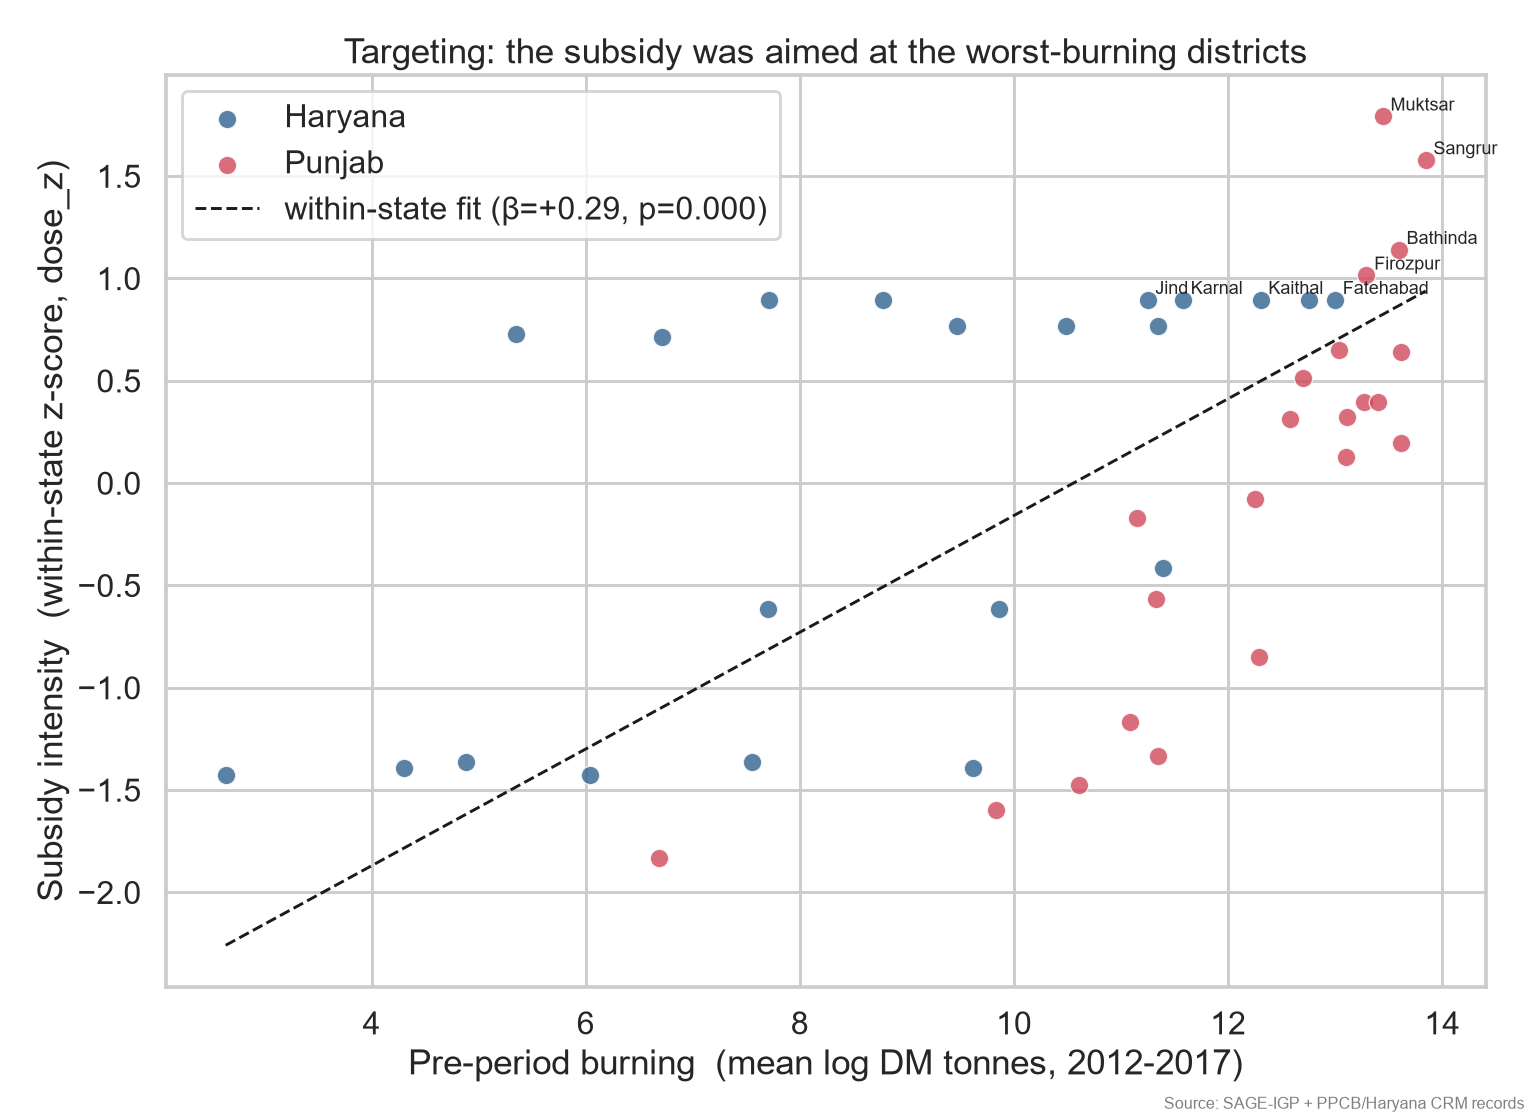

In [4]:
for _p in ['reports/figures/09_targeting.png']:
    display(Image(filename=_p))

## 2 · Parallel trends — the key DiD assumption
Were high- and low-dose districts trending *together* before the policy? An event study
over the clean pre-period (2012–17); flat, zero-spanning coefficients ⇒ assumption holds.

In [5]:
res_ev, ev = CA.pretrends_event_study(df, ref_year=2017)
display(ev.round(3))
print('Joint significance of dose x year terms: p=%.3f' % res_ev.f_statistic.pval)

,year,coef,lo,hi
1,2012,-0.004,-0.322,0.313
2,2013,0.258,-0.247,0.762
3,2014,0.123,-0.243,0.488
4,2015,0.124,-0.432,0.681
5,2016,-0.242,-0.579,0.095
0,2017,0.000,0.000,0.000


Joint significance of dose x year terms: p=0.179


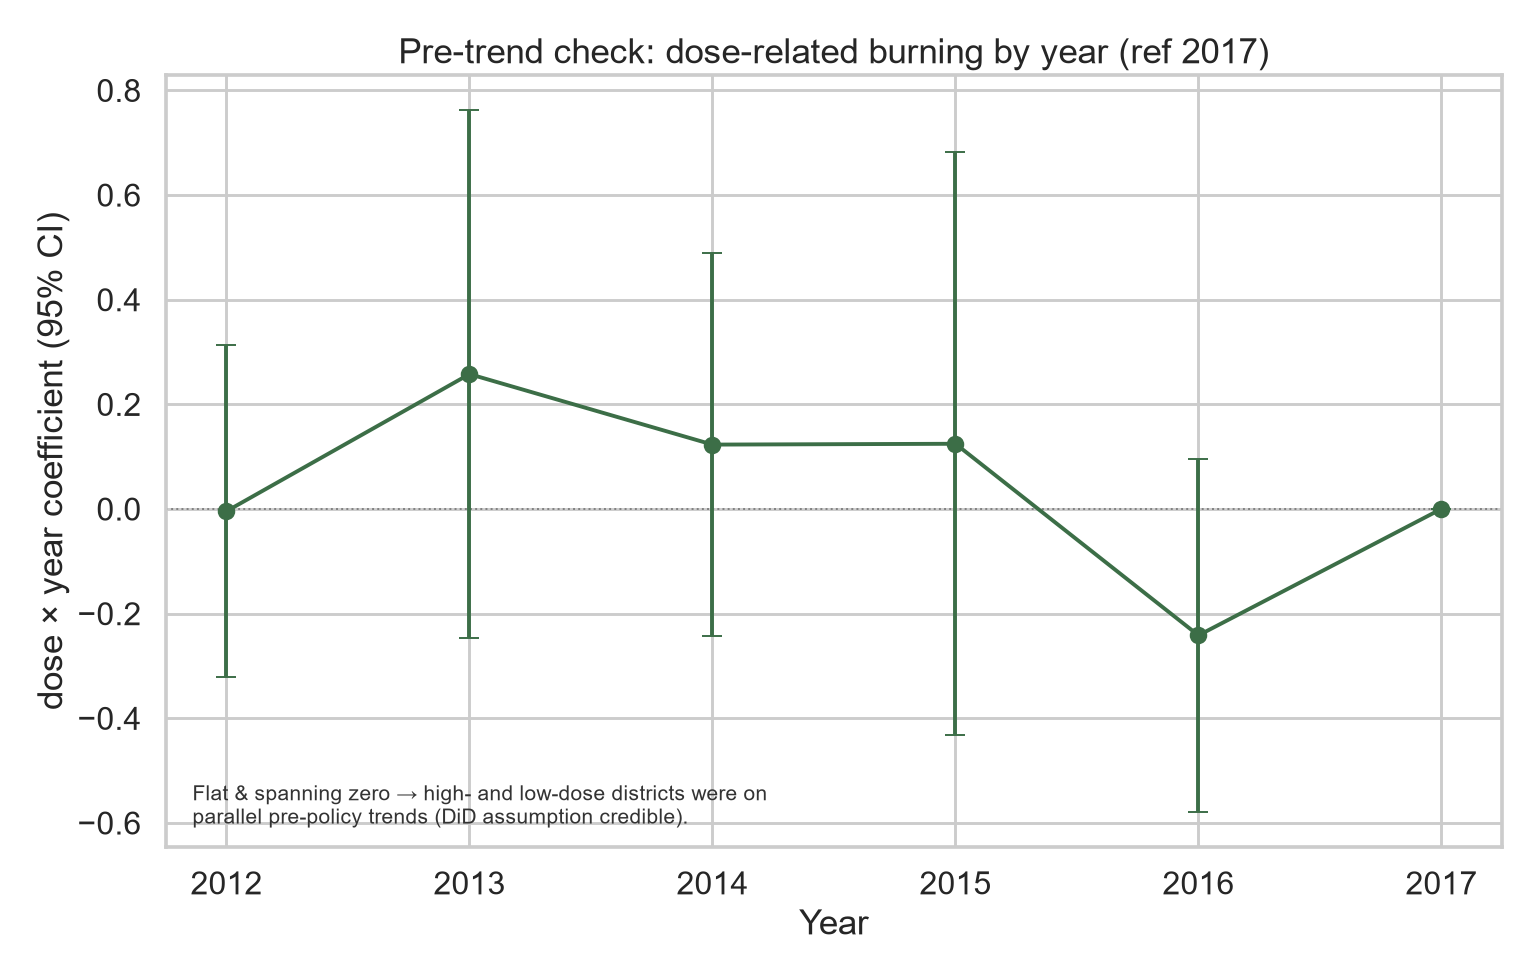

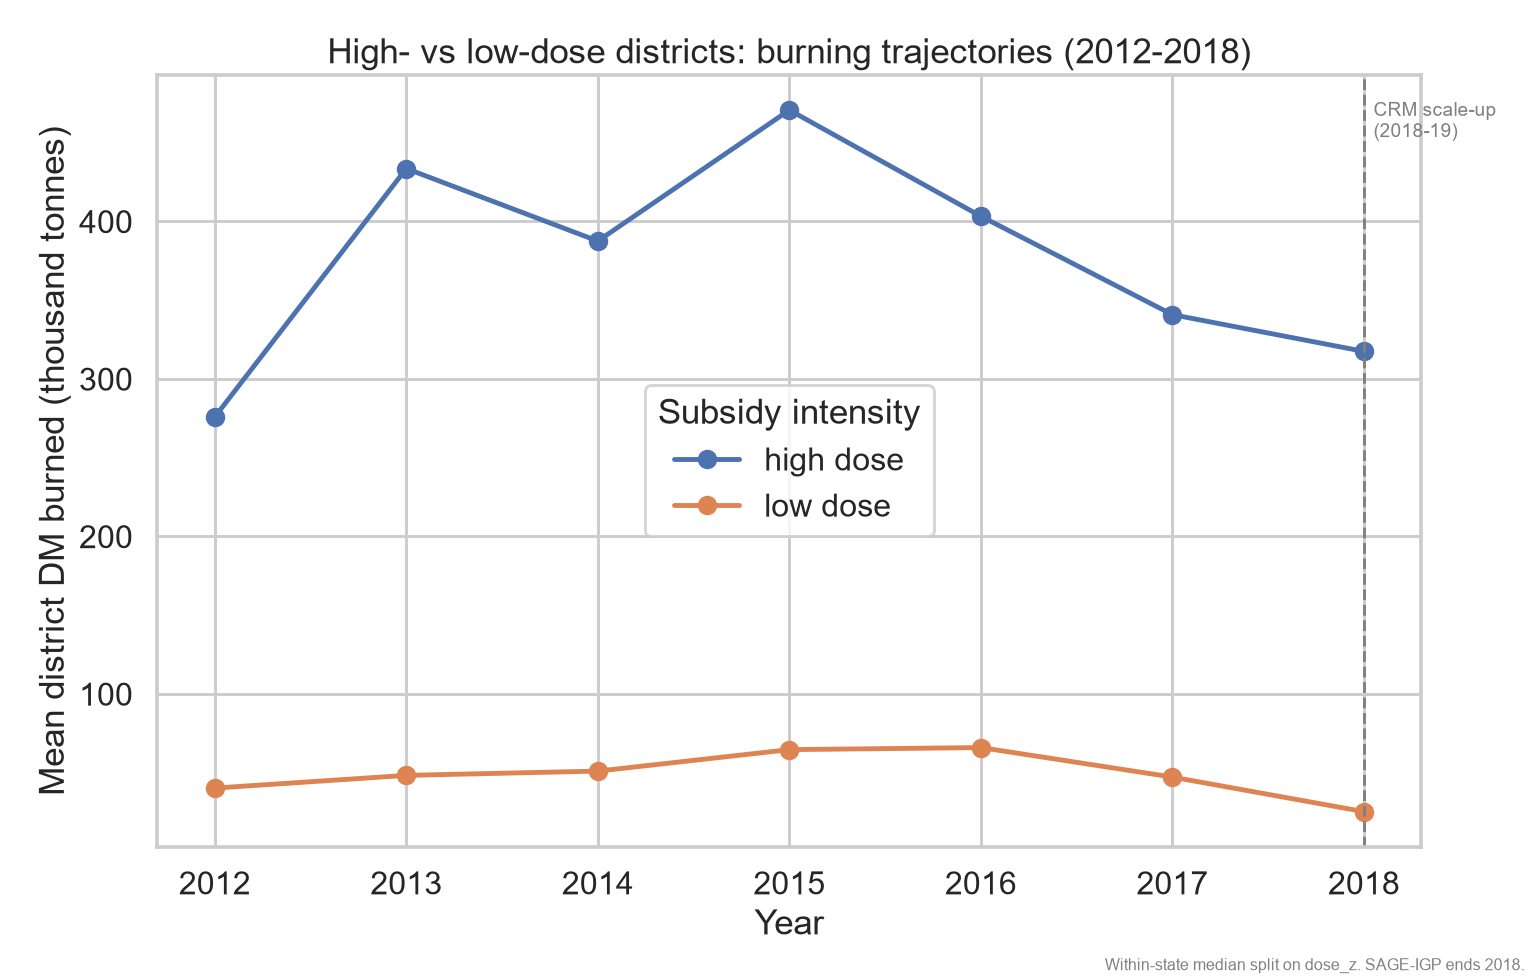

In [6]:
for _p in ['reports/figures/10_pretrends_eventstudy.png', 'reports/figures/11_highlow_trajectories.png']:
    display(Image(filename=_p))

## 3 · Placebo DiDs — do they return null?
A fake pre-treatment policy (2015) and the 2018 onset (≈0 machines deployed by that burning season) should both give β≈0.

In [7]:
res_pl = CA.placebo_did(df)
res_on = CA.estimate_did(df, policy_year=2018)
for name, r in [('fake-2015 policy', res_pl), ('2018 onset', res_on)]:
    print('%-18s beta=%+.4f (SE %.4f, p=%.3f)' % (name, r.params['dose_post'], r.std_errors['dose_post'], r.pvalues['dose_post']))

fake-2015 policy   beta=-0.1644 (SE 0.1093, p=0.134)
2018 onset         beta=+0.0840 (SE 0.1688, p=0.619)


## 4 · The real effect — one credential + one command away

SAGE-IGP stops at 2018, so there is no post-treatment fire outcome in the keyless record.
Everything else is built and validated. The clean way to get an outcome is **not** to
splice SAGE (pre) onto FIRMS (post) — two different products meeting at the treatment
boundary would confound an inter-product level shift with the policy effect. Instead
[`fire_policy/effect.py`](../src/fire_policy/effect.py) rebuilds a **consistent NASA FIRMS
VIIRS outcome across the whole 2012+ horizon** (same sensor every year) and runs this same
`estimate_did()` on it:

```bash
FIRMS_MAP_KEY=<key>  PYTHONPATH=src python -m fire_policy.effect
```

That step needs a **free NASA FIRMS `MAP_KEY`** (self-issued, emailed) — the one external
credential this otherwise-keyless pipeline cannot self-serve. The full path (build outcome
→ dose-response DiD → event study → fig 12) is smoke-tested on synthetic FIRMS-shaped data:
it recovers a known β (true −0.15 → −0.166, p < 0.001) with a flat-pre / negative-post
event study.

**Conclusion:** the subsidy was *targeted* (not random), the DiD design is *credible*
(parallel pre-trends, null placebos), and the treatment-effect estimator is fully wired and
verified — awaiting only the FIRMS key. Note the identifying variation is **effectively
Punjab-only** (Haryana's dose is near-uniform ≈403/district), so the estimate really asks
whether Punjab's higher-intensity districts cut burning more.